In [1]:
from functools import reduce
from collections import defaultdict
from dataclasses import dataclass

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [2]:
import sys
sys.path.append(r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\TRACE\evaluate')

In [3]:
import eval_20Minuten
import eval_CStance
import eval_FOMC
import eval_MeetingBank
import eval_NumGLUE_ds
import eval_NumGLUE_cm
import eval_PapyrusF
import eval_Py150
import eval_ScienceQA

## Loading predictions

In [4]:
base_path = r"C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\TRACE"

# dataset_names = ['20Minuten', 'FOMC', 'MeetingBank', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'Lima', 'NumGLUE-cm', 'Py150']  # All benchmarks
All_dataset_names = ['20Minuten', 'FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm', 'Py150']                       # Benchmarks in use
tasks_to_load = ['20Minuten', 'FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm']
dataset_names = ['20Minuten', 'FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm']

preds_dict = defaultdict(lambda: dict())

Загрузка Raw

In [5]:
# for dataset_name in dataset_names:
#     path = rf"C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\TRACE\preds\Raw\{dataset_name}.bin"

#     with open(path, 'rb') as f:
#         preds_dict['Raw'][dataset_name] = pickle.load(file=f)

Загрузка дообученных

In [6]:
@dataclass
class ExperimentRun:
    model_name: str
    adapter_name: str = None
    cfg: int = None
    seq: int = None
    seq_task: str = None

    def get_base_pth(self) -> str:
        path = rf"{base_path}\preds\{self.model_name}"
        if self.adapter_name:
            path += f"-{self.adapter_name}"
        if self.cfg:
            path += f"-cfg{self.cfg}"
        if self.seq:
            path += f"\seq-{self.seq}"
        if self.seq_task:
            path += f"\{self.seq_task}"
        # path = rf"{base_path}\preds\{self.model_name}-{self.adapter_name}-cfg{self.cfg}\seq-{self.seq}\{self.seq_task}"

        return path
    
    def get_run_name(self) -> str:
        if self.adapter_name:
            run_name = self.adapter_name
        else:
            run_name = self.model_name
            
        if self.cfg:
            run_name += f"-cfg{self.cfg}"
        if self.seq:
            run_name += f"-{self.seq}"
        if self.seq_task:
            run_name += f"-{self.seq_task}"
        # run_name = f"{self.adapter_name}-cfg{self.cfg}-{self.seq}-{self.seq_task}"

        return run_name

In [7]:
experiments = [
    ExperimentRun(model_name='Raw')
]

experiments += [
    ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task=seq_task)
    for seq_task in tasks_to_load
]

experiments += [
    ExperimentRun(model_name='Llama-32-1b', adapter_name='SemiLoRA', cfg=1, seq=1, seq_task=seq_task)
    for seq_task in tasks_to_load
]

experiments += [
    ExperimentRun(model_name='Llama-32-1b', adapter_name='GSOFT', cfg=3, seq=1, seq_task=seq_task)
    for seq_task in tasks_to_load
]

experiments

[ExperimentRun(model_name='Raw', adapter_name=None, cfg=None, seq=None, seq_task=None),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='20Minuten'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='FOMC'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='NumGLUE-ds'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='ScienceQA'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='C-STANCE'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='NumGLUE-cm'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='SemiLoRA', cfg=1, seq=1, seq_task='20Minuten'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='SemiLoRA', cfg=1, seq=1, seq_task='FOMC'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='SemiLoRA', cfg=1, seq=1, seq_task='NumGLUE-ds'),
 ExperimentRun(mo

In [8]:
experiments[1].get_run_name()

'LoRA-cfg2-1-20Minuten'

In [9]:
for experiment in experiments:
    run_name = experiment.get_run_name()
    print(f"Loading {run_name}")

    for dataset_name in dataset_names:
        path = rf"{experiment.get_base_pth()}\{dataset_name}.bin"

        with open(path, 'rb') as f:
            preds_dict[run_name][dataset_name] = pickle.load(file=f)

Loading Raw
Loading LoRA-cfg2-1-20Minuten
Loading LoRA-cfg2-1-FOMC
Loading LoRA-cfg2-1-NumGLUE-ds
Loading LoRA-cfg2-1-ScienceQA
Loading LoRA-cfg2-1-C-STANCE
Loading LoRA-cfg2-1-NumGLUE-cm
Loading SemiLoRA-cfg1-1-20Minuten
Loading SemiLoRA-cfg1-1-FOMC
Loading SemiLoRA-cfg1-1-NumGLUE-ds
Loading SemiLoRA-cfg1-1-ScienceQA
Loading SemiLoRA-cfg1-1-C-STANCE
Loading SemiLoRA-cfg1-1-NumGLUE-cm
Loading GSOFT-cfg3-1-20Minuten
Loading GSOFT-cfg3-1-FOMC
Loading GSOFT-cfg3-1-NumGLUE-ds
Loading GSOFT-cfg3-1-ScienceQA
Loading GSOFT-cfg3-1-C-STANCE
Loading GSOFT-cfg3-1-NumGLUE-cm


In [10]:
# preds_dict['GSOFT-cfg2-1-FOMC']['FOMC']

### Evaluation

In [11]:
eval_functions = {
    '20Minuten': eval_20Minuten.eval, 
    'FOMC': eval_FOMC.eval, 
    'NumGLUE-ds': eval_NumGLUE_ds.eval, 
    'ScienceQA': eval_ScienceQA.eval, 
    'C-STANCE': eval_CStance.eval, 
    'NumGLUE-cm': eval_NumGLUE_cm.eval,
    'Py150': eval_Py150.eval,
}

def calc_scores(preds_dfs):
    eval_scores = {}

    for dataset_name in dataset_names:
        print(f"Running for {dataset_name}")
        preds_df = preds_dfs[dataset_name]

        correct_answers = list(preds_df['answer'])
        model_preds = [pred['generated_text'].strip() for pred in preds_df['model_pred']]

        if dataset_name != '20Minuten':
            eval_scores[dataset_name] = eval_functions[dataset_name](model_preds, correct_answers)
        else:
            input_seq = list(preds_df['prompt'])
            eval_scores[dataset_name] = eval_functions[dataset_name](input_seq, model_preds, correct_answers)
    
    return eval_scores

In [13]:
scores_dict = {
    run_name: calc_scores(preds_dfs)
    for run_name, preds_dfs in preds_dict.items()
}

Running for 20Minuten


c:\python_venvs\ml_venv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\python_venvs\ml_venv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\python_venvs\ml_venv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.

Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-c

**Raw**

In [14]:
for dataset_name in dataset_names:
    eval_score = scores_dict['Raw'][dataset_name]

    print(f"{dataset_name}:\n    ", '\n    '.join(f"{key}: {val}" for key, val in eval_score.items()))
    print("\n")

20Minuten:
     bleu-1: 0.09321426467245647
    bleu-4: 0.0069805684871051136
    rouge-L: 0.16469634531039795
    sari: ({'sari': 36.157578040864465},)


FOMC:
     accuracy: 0.2762096774193548


NumGLUE-ds:
     accuracy: 0.2553846153846154


ScienceQA:
     bleu-1: 0.0961470986274449
    bleu-4: 0.02091741115466068
    accuracy: 0.6615


C-STANCE:
     accuracy: 0.332


NumGLUE-cm:
     accuracy: 0.14814814814814814




**20Minuten-FT**

In [15]:
for dataset_name in dataset_names:
    eval_score = scores_dict['LoRA-cfg2-1-20Minuten'][dataset_name]

    print(f"{dataset_name}:\n    ", '\n    '.join(f"{key}: {val}" for key, val in eval_score.items()))
    print("\n")

20Minuten:
     bleu-1: 0.030412970520981842
    bleu-4: 0.002988248090165529
    rouge-L: 0.21327036866162444
    sari: ({'sari': 36.88976711263668},)


FOMC:
     accuracy: 0.0


NumGLUE-ds:
     accuracy: 0.0


ScienceQA:
     bleu-1: 0.012091269010297749
    bleu-4: 0.0027970389550073535
    accuracy: 0.0625


C-STANCE:
     accuracy: 0.002


NumGLUE-cm:
     accuracy: 0.012345679012345678




**FOMC-FT**

In [16]:
for dataset_name in dataset_names:
    eval_score = scores_dict['LoRA-cfg2-1-FOMC'][dataset_name]

    print(f"{dataset_name}:\n    ", '\n    '.join(f"{key}: {val}" for key, val in eval_score.items()))
    print("\n")

20Minuten:
     bleu-1: 0.030291717078598904
    bleu-4: 0.003368439621795806
    rouge-L: 0.17939702987220077
    sari: ({'sari': 36.00884800539547},)


FOMC:
     accuracy: 0.6713709677419355


NumGLUE-ds:
     accuracy: 0.06769230769230769


ScienceQA:
     bleu-1: 0.016812816595577255
    bleu-4: 0.005422359298127174
    accuracy: 0.601


C-STANCE:
     accuracy: 0.4005


NumGLUE-cm:
     accuracy: 0.06172839506172839




### Visualization

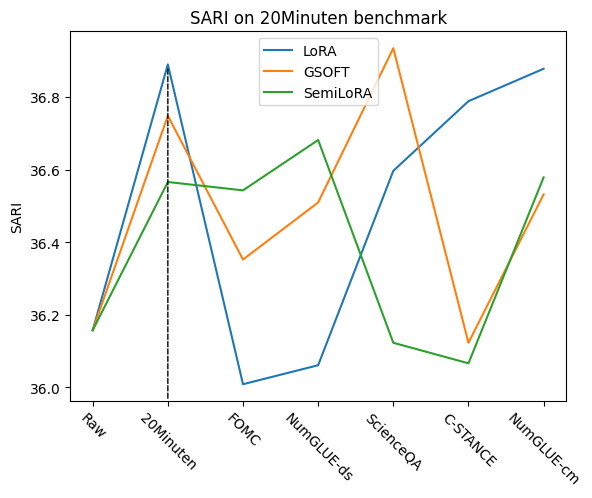

In [17]:
bench_name = '20Minuten'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['sari'][0]['sari'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['sari'][0]['sari'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['sari'][0]['sari'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['sari'][0]['sari']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + tasks_to_load, 
    rotation=-45
)

plt.ylabel('SARI')
plt.title(f'SARI on {bench_name} benchmark')
plt.legend()

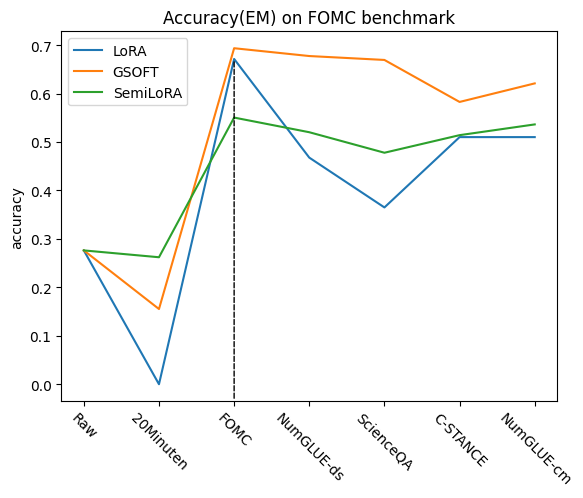

In [18]:
bench_name = 'FOMC'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

# bbox = dict(boxstyle ="round", fc ="0.8") 
# arrowprops = dict( 
#     arrowstyle = "->", 
#     connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
# ) 
  
# plt.annotate(
#     text='FT', 
#     xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
#     xytext =(30, -20), 
#     textcoords ='offset points', 
#     bbox = bbox, arrowprops = arrowprops
# ) 

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + tasks_to_load, 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

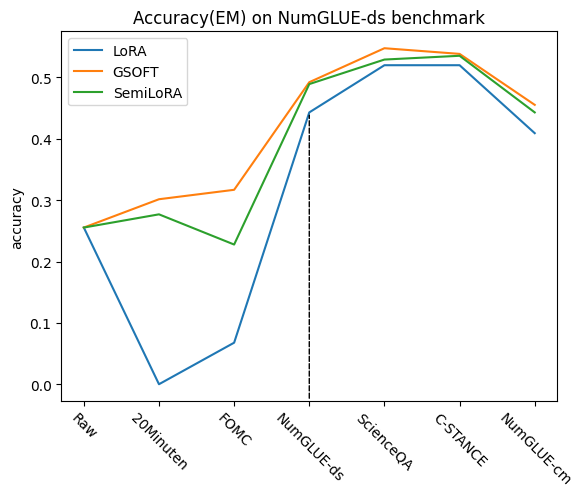

In [19]:
bench_name = 'NumGLUE-ds'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

# bbox = dict(boxstyle ="round", fc ="0.8") 
# arrowprops = dict( 
#     arrowstyle = "->", 
#     connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
# ) 
 

# plt.annotate(
#     text='FT', 
#     xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
#     xytext=(30, -20), 
#     textcoords ='offset points', 
#     bbox = bbox, arrowprops = arrowprops
# ) 

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + tasks_to_load, 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

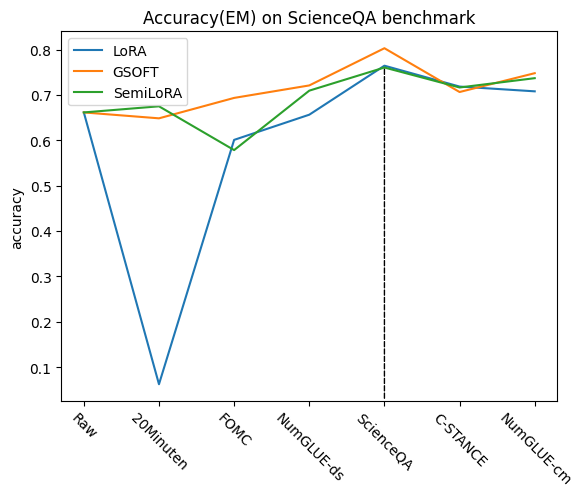

In [20]:
bench_name = 'ScienceQA'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)


bbox = dict(boxstyle ="round", fc ="0.8") 
# arrowprops = dict( 
#     arrowstyle = "->", 
#     connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
# ) 
  
# plt.annotate(
#     text='FT', 
#     xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
#     xytext =(30, -20), 
#     textcoords ='offset points', 
#     bbox = bbox, arrowprops = arrowprops
# ) 

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + tasks_to_load, 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

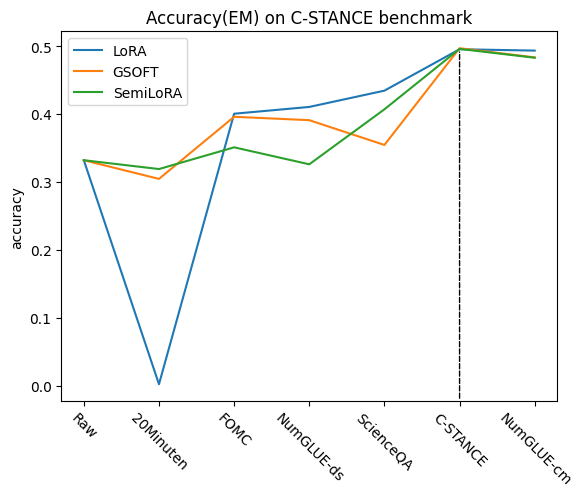

In [21]:
bench_name = 'C-STANCE'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

# bbox = dict(boxstyle ="round", fc ="0.8") 
# arrowprops = dict( 
#     arrowstyle = "->", 
#     connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
# ) 
  
# plt.annotate(
#     text='FT', 
#     xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
#     xytext =(30, -20), 
#     textcoords ='offset points', 
#     bbox = bbox, arrowprops = arrowprops
# ) 

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + tasks_to_load, 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

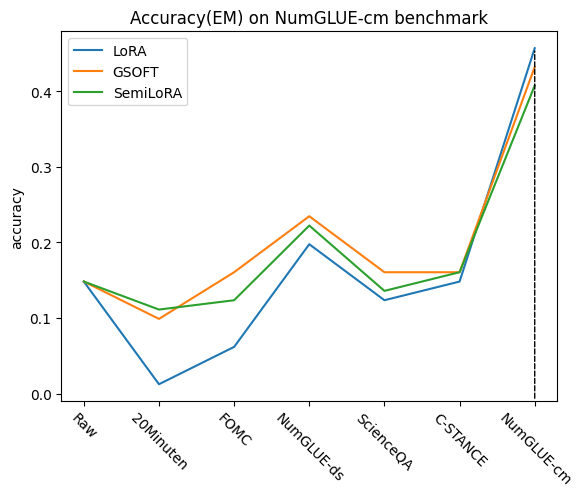

In [22]:
bench_name = 'NumGLUE-cm'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

# bbox = dict(boxstyle ="round", fc ="0.8") 
# arrowprops = dict( 
#     arrowstyle = "->", 
#     connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
# ) 
  
# plt.annotate(
#     text='FT', 
#     xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
#     xytext =(30, -20), 
#     textcoords ='offset points', 
#     bbox = bbox, arrowprops = arrowprops
# ) 

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + tasks_to_load, 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

In [23]:
# np.exp2(np.random.uniform(1, 16, size=8)).astype(np.int64)

In [24]:
# import json

# A_datasets = ['C-STANCE', 'FOMC', 'MeetingBank', 'Py150', 'ScienceQA', 'NumGLUE-cm', 'NumGLUE-ds', '20Minuten']
# A_seeds = [17685,  2120,   716,   109,    94, 12296, 10084,  4369]


# with open('./seeds.json', 'w') as f:
#     json.dump(
#         obj={
#             A_ds: A_ep
#             for A_ds, A_ep in zip(A_datasets, A_seeds)
#         },
#         fp=f
#     )

In [25]:
# set(A_datasets) - set(dataset_names)

In [26]:
# AAA_bs = {}

# for ds_name in All_dataset_names:
#     if ds_name in ('Py150', '20Minuten', 'ScienceQA'):
#         AAA_bs[ds_name] = 4
#     else:
#         AAA_bs[ds_name] = 8

# import json
# json.dumps(AAA_bs)